검색된 VISA 장비 목록:
  [0] USB0::0x1AB1::0x0610::HDO1B250500121::INSTR
연결 성공: RIGOL TECHNOLOGIES,DHO1104,HDO1B250500121,00.02.04

채널 1 파형 데이터 캡처 시작...

--- 파형 파라미터 ---
  X Increment : 5.000000e-03 s
  X Origin    : -5.000000e+00 s
  Y Increment : 1.707000e-03 V
  Y Origin    : 0.000000e+00 V
  Y Reference : 128.0
  수신 포인트 수: 1000 (BYTE/8bit)

--- 결과 요약 ---
  포인트 수 : 1000
  시간 범위 : -5.000000e+00 ~ -5.000000e-03 s
  전압 범위 : -0.039261000000 ~ 0.039261000000 V
  전압 평균 : -0.000247515000 V
  전압 표준편차  : 0.029469070211 V
CSV 저장 완료: waveform.csv (1000 points)
그래프 저장: waveform.png


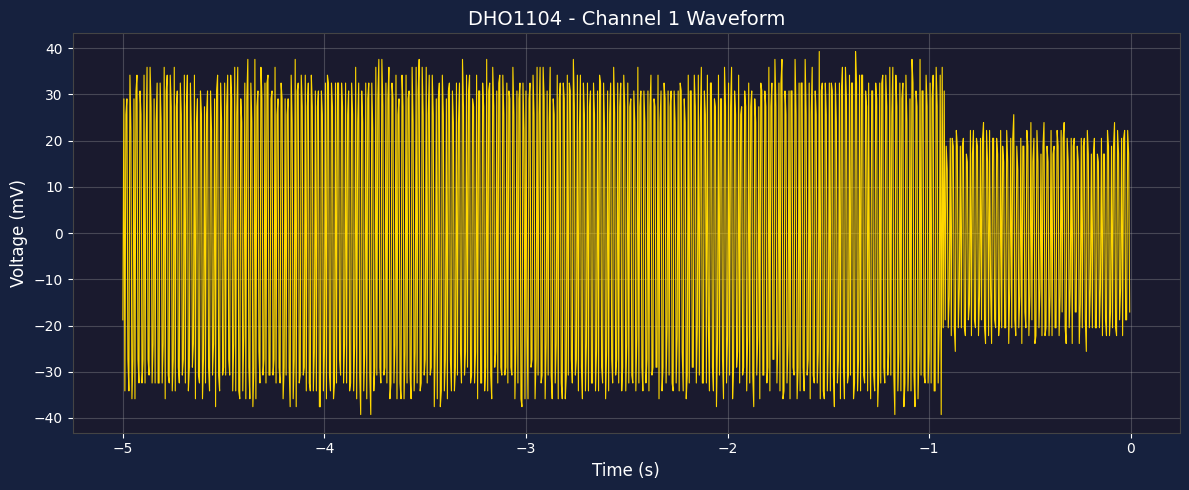

-200,"Command execute failed"

연결 종료.


In [ ]:
"""
Rigol DHO1104 오실로스코프 파형 데이터 캡처 스크립트
=====================================================
pyvisa를 사용하여 DHO1104에서 파형 데이터를 읽어오고
전압으로 변환한 뒤 그래프로 표시합니다.

사전 설치:
    pip install pyvisa pyvisa-py numpy matplotlib

USB 연결 시 NI-VISA 또는 pyvisa-py 백엔드 필요
LAN 연결 시 pyvisa-py만으로도 동작 가능
"""

import pyvisa
import numpy as np
import matplotlib.pyplot as plt
import time
import sys


# ============================================================
# 설정값 (사용 환경에 맞게 수정하세요)
# ============================================================
# USB 연결 예시: "USB0::0x1AB1::0x044C::DHO1A000000000::INSTR"
# LAN 연결 예시: "TCPIP0::192.168.1.100::INSTR"
VISA_ADDRESS = "USB0::0x1AB1::0x0610::HDO1B250500121::INSTR"

CHANNEL = 2          # 읽을 채널 (1~4)
WAV_MODE = "NORMal"   # NORMal: 화면 포인트, RAW: 메모리 전체, MAXimum: 자동
WAV_FORMAT = "BYTE"   # BYTE: 8bit, WORD: 16bit(12bit 정밀도), ASCii: 텍스트
START_POINT = 1       # 읽기 시작점
STOP_POINT = 1200     # 읽기 종료점 (NORMal 모드 기본 ~1200)


def find_instruments():
    """연결 가능한 VISA 장비 목록을 검색합니다."""
    rm = pyvisa.ResourceManager()
    resources = rm.list_resources()
    print("=" * 60)
    print("검색된 VISA 장비 목록:")
    print("=" * 60)
    if not resources:
        print("  (장비가 발견되지 않았습니다)")
        print("  - USB 케이블 연결 확인")
        print("  - NI-VISA 드라이버 설치 확인")
        print("  - 오실로스코프 전원 확인")
    else:
        for i, res in enumerate(resources):
            print(f"  [{i}] {res}")
    print("=" * 60)
    rm.close()
    return resources


def connect(visa_address):
    """오실로스코프에 연결합니다."""
    rm = pyvisa.ResourceManager()
    try:
        inst = rm.open_resource(visa_address)
        inst.timeout = 10000      # 타임아웃 10초
        inst.read_termination = '\n'
        inst.write_termination = '\n'
        inst.chunk_size = 1024 * 1024  # 1MB 청크 (대용량 데이터용)

        # 장비 확인
        idn = inst.query("*IDN?")
        print(f"연결 성공: {idn.strip()}")
        return rm, inst
    except Exception as e:
        print(f"연결 실패: {e}")
        rm.close()
        sys.exit(1)


def get_waveform_params(inst):
    """파형 변환에 필요한 스케일링 파라미터를 읽습니다."""
    params = {}
    params['xinc'] = float(inst.query(":WAV:XINC?"))     # X축 시간 간격 (초)
    params['xor'] = float(inst.query(":WAV:XOR?"))       # X축 시작 시간
    params['xref'] = float(inst.query(":WAV:XREF?"))     # X축 레퍼런스
    params['yinc'] = float(inst.query(":WAV:YINC?"))     # Y축 전압 증분
    params['yor'] = float(inst.query(":WAV:YOR?"))       # Y축 전압 오프셋
    params['yref'] = float(inst.query(":WAV:YREF?"))     # Y축 레퍼런스

    print("\n--- 파형 파라미터 ---")
    print(f"  X Increment : {params['xinc']:.6e} s")
    print(f"  X Origin    : {params['xor']:.6e} s")
    print(f"  Y Increment : {params['yinc']:.6e} V")
    print(f"  Y Origin    : {params['yor']:.6e} V")
    print(f"  Y Reference : {params['yref']}")
    return params


def capture_waveform(inst, channel=1, mode="NORMal", fmt="BYTE",
                     start=1, stop=1200):
    """
    오실로스코프에서 파형 데이터를 읽어옵니다.

    Parameters
    ----------
    inst : pyvisa.Resource
        연결된 오실로스코프 리소스
    channel : int
        채널 번호 (1~4)
    mode : str
        "NORMal" / "RAW" / "MAXimum"
    fmt : str
        "BYTE" / "WORD" / "ASCii"
    start : int
        읽기 시작 포인트
    stop : int
        읽기 종료 포인트

    Returns
    -------
    raw_data : numpy.ndarray
        Raw 데이터 배열
    params : dict
        스케일링 파라미터
    """
    print(f"\n채널 {channel} 파형 데이터 캡처 시작...")

    # 1) 오실로스코프 정지
    inst.write(":STOP")
    time.sleep(0.5)

    # 2) 파형 소스 설정
    inst.write(f":WAV:SOUR CHAN{channel}")
    time.sleep(0.1)

    # 3) 읽기 모드 설정
    inst.write(f":WAV:MODE {mode}")
    time.sleep(0.1)

    # 4) 데이터 포맷 설정
    inst.write(f":WAV:FORM {fmt}")
    time.sleep(0.1)

    # 5) 스케일링 파라미터 읽기
    params = get_waveform_params(inst)

    # 6) 읽기 범위 설정
    inst.write(f":WAV:STAR {start}")
    inst.write(f":WAV:STOP {stop}")
    time.sleep(0.1)

    # 7) 데이터 요청 및 수신
    if fmt.upper() == "ASCII" or fmt.upper() == "ASC":
        # ASCii 모드: 쉼표로 구분된 텍스트
        raw_str = inst.query(":WAV:DATA?")
        raw_data = np.array([float(x) for x in raw_str.split(',') if x.strip()])
        print(f"  수신 포인트 수: {len(raw_data)} (ASCii)")

    elif fmt.upper() == "WORD":
        # WORD 모드: 16bit 바이너리 (12bit 해상도 활용)
        raw_bytes = inst.query_binary_values(
            ":WAV:DATA?",
            datatype='H',           # unsigned short (2 bytes)
            is_big_endian=False,     # Little Endian
            container=np.array
        )
        raw_data = raw_bytes.astype(np.float64)
        print(f"  수신 포인트 수: {len(raw_data)} (WORD/16bit)")

    else:
        # BYTE 모드: 8bit 바이너리
        raw_bytes = inst.query_binary_values(
            ":WAV:DATA?",
            datatype='B',           # unsigned byte
            is_big_endian=False,
            container=np.array
        )
        raw_data = raw_bytes.astype(np.float64)
        print(f"  수신 포인트 수: {len(raw_data)} (BYTE/8bit)")

    return raw_data, params


def convert_to_voltage(raw_data, params):
    """
    Raw 데이터를 실제 전압값으로 변환합니다.

    공식: Voltage = (Raw - YReference - YOrigin) × YIncrement
    """
    voltage = (raw_data - params['yref'] - params['yor']) * params['yinc']
    return voltage


def generate_time_axis(num_points, params):
    """
    시간축 배열을 생성합니다.

    공식: Time[i] = XIncrement × i + XOrigin
    """
    time_arr = np.arange(num_points) * params['xinc'] + params['xor']
    return time_arr


def capture_screen(inst, filename="screenshot.png"):
    """
    오실로스코프 화면을 PNG 이미지로 캡처합니다.

    Parameters
    ----------
    inst : pyvisa.Resource
        연결된 오실로스코프 리소스
    filename : str
        저장할 파일명
    """
    print(f"\n화면 캡처 중...")
    raw = inst.query_binary_values(
        ":DISP:DATA? PNG",
        datatype='B',
        container=bytearray
    )
    with open(filename, 'wb') as f:
        f.write(raw)
    print(f"화면 캡처 저장 완료: {filename}")


def plot_waveform(time_arr, voltage, channel=1):
    """파형 데이터를 그래프로 표시합니다."""
    # 시간축 단위 자동 조정
    t_max = abs(time_arr[-1] - time_arr[0])
    if t_max < 1e-6:
        t_scale, t_unit = 1e9, "ns"
    elif t_max < 1e-3:
        t_scale, t_unit = 1e6, "μs"
    elif t_max < 1:
        t_scale, t_unit = 1e3, "ms"
    else:
        t_scale, t_unit = 1, "s"

    # 전압축 단위 자동 조정
    v_max = max(abs(voltage.max()), abs(voltage.min()))
    if v_max < 1e-3:
        v_scale, v_unit = 1e6, "μV"
    elif v_max < 1:
        v_scale, v_unit = 1e3, "mV"
    else:
        v_scale, v_unit = 1, "V"

    plt.figure(figsize=(12, 5))
    plt.plot(time_arr * t_scale, voltage * v_scale, linewidth=0.8, color='#FFD700')
    plt.xlabel(f"Time ({t_unit})", fontsize=12)
    plt.ylabel(f"Voltage ({v_unit})", fontsize=12)
    plt.title(f"DHO1104 - Channel {channel} Waveform", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.gca().set_facecolor('#1a1a2e')
    plt.gcf().set_facecolor('#16213e')
    plt.tick_params(colors='white')
    plt.xlabel(f"Time ({t_unit})", fontsize=12, color='white')
    plt.ylabel(f"Voltage ({v_unit})", fontsize=12, color='white')
    plt.title(f"DHO1104 - Channel {channel} Waveform", fontsize=14, color='white')
    for spine in plt.gca().spines.values():
        spine.set_color('#444')
    plt.tight_layout()
    plt.savefig("waveform.png", dpi=150, facecolor='#16213e')
    print("그래프 저장: waveform.png")
    plt.show()


def save_csv(time_arr, voltage, filename="waveform.csv"):
    """파형 데이터를 CSV 파일로 저장합니다."""
    data = np.column_stack((time_arr, voltage))
    np.savetxt(filename, data, delimiter=',',
               header='Time(s),Voltage(V)', comments='')
    print(f"CSV 저장 완료: {filename} ({len(voltage)} points)")


# ============================================================
# 메인 실행
# ============================================================
if __name__ == "__main__":

    # --- 장비 검색 ---
    resources = find_instruments()

    # --- 연결 (주소를 환경에 맞게 수정하세요) ---
    # 검색된 장비 중 첫 번째를 자동 사용하려면:
    #   address = resources[0] if resources else VISA_ADDRESS
    address = VISA_ADDRESS
    rm, inst = connect(address)
    inst.write("*CLS")

    try:
        # --- 파형 데이터 캡처 ---
        raw_data, params = capture_waveform(
            inst,
            channel=CHANNEL,
            mode=WAV_MODE,
            fmt=WAV_FORMAT,
            start=START_POINT,
            stop=STOP_POINT
        )

        # --- 전압 변환 ---
        voltage = convert_to_voltage(raw_data, params)
        time_arr = generate_time_axis(len(voltage), params)

        print(f"\n--- 결과 요약 ---")
        print(f"  포인트 수 : {len(voltage)}")
        print(f"  시간 범위 : {time_arr[0]:.6e} ~ {time_arr[-1]:.6e} s")
        print(f"  전압 범위 : {voltage.min():.12f} ~ {voltage.max():.12f} V")
        print(f"  전압 평균 : {voltage.mean():.12f} V")
        print(f"  전압 표준편차  : {np.std(voltage, ddof=1):.12f} V")

        # --- CSV 저장 ---
        save_csv(time_arr, voltage)

        # --- 그래프 표시 ---
        plot_waveform(time_arr, voltage, channel=CHANNEL)

        # --- (선택) 화면 캡처 ---
        # capture_screen(inst, "screenshot.png")

    finally:
        # --- 연결 종료 ---
        inst.write(":RUN")   # 오실로스코프 다시 동작 시작
        print(inst.query(":SYST:ERR?"))
        inst.close()
        rm.close()
        print("\n연결 종료.")